In [1]:
from IPython.display import display, HTML

# 1.**RESUMEN:**

Este estudio evalúa la capacidad discriminativa de descriptores de electroencefalografía (EEG) y la topología de algoritmos predictivos en la decodificación de la imaginación motora (izquierda, derecha y reposo) para el desarrollo de Interfaces Cerebro-Computadora (BCI) no invasivas. Se extrajeron 16 características espectrales, temporales y espaciales (PSD, Wavelet, Hjorth, ASI) de los canales motores C3 y C4. El análisis exploratorio confirmó la presencia de Desincronización Relacionada con Eventos (ERD) y asimetría hemisférica, pero reveló una alta redundancia multivariable y superposición inter-clase. Para la clasificación, se garantizó la estabilidad evaluativa mediante validación cruzada Stratified K-Fold, comparando Perceptrones Multicapa (MLP) dimensionados mediante reglas heurísticas (4, 6 y 8 neuronas), Máquinas de Vectores de Soporte (SVM-RBF) y XGBoost. Los resultados demostraron que, si bien el dimensionamiento heurístico del MLP (Arquitectura 3) eliminó exitosamente el sobreajuste (Good fit con brechas < 2.5%), la exactitud de prueba (Accuracy) convergió sistemáticamente en un techo del ~42.7% a través de todos los modelos. Mientras que algoritmos no lineales como XGBoost sufrieron de memorización de ruido y sesgo hacia la clase mayoritaria (reposo), el SVM exhibió un fuerte desplazamiento hacia la imaginación izquierda. Estos hallazgos concluyen que el factor limitante del sistema no es la capacidad representacional de los clasificadores, sino la baja separabilidad topológica de los datos, estableciendo la reducción de dimensionalidad y el balanceo estricto de clases como los pasos críticos para futuras optimizaciones.

# 2.1. **DESCRIPCIÓN DEL PROYECTO:** 

<p style="margin-left: 25px; text-align: justify;">
Para este proyecto, el dataset utilizado es el mismo del proyecto 1 el cual contiene 1500 registros de EEG de uno y dos minutos de duración obtenidos de 109 voluntarios sanos. Las señales se adquirieron mediante 64 canales de EEG usando el sistema BCI2000, con el montaje internacional 10-10 (excluyendo electrodos Nz, F9, F10, FT9, FT10, A1, A2, TP9, TP10, P9 y P10).
El objetivo de estas señales es evaluar la factibilidad de construir sistemas BCI no invasivos, teniendo en cuenta el conocimiento que se tiene del funcionamiento cerebral para el control de movimiento, los segmentos relacionados con las condiciones de interés deben ser procesados para eliminar artefactos y extraer índices o características relevantes.
</p>

<p style="margin-left: 25px; text-align: justify;">
Cada sujeto realizó 14 corridas experimentales como se muestra en la Tabla 1. 
</p>

<table style="border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; font-size: 14px; color: black;">
  <caption style="font-weight: bold; text-align: left; margin-bottom: 6px; font-size: 14px; color: black;">
    Tabla 1. Información de corridas por sujeto.
  </caption>
  <thead>
    <tr style="background-color: #2c3e50; color: black;">
      <th style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">Corridas</th>
      <th style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">Tipo</th>
      <th style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">Descripción de la tarea</th>
      <th style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">Duración</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f9f9f9;">
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">1</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">Línea base</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px;">Reposo con ojos abiertos</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">1 minuto</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">2</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">Línea base</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px;">Reposo con ojos cerrados</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">1 minuto</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">4, 8, 12</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">Tarea 2</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px;"><strong>Imaginación</strong> de apertura y cierre del puño izquierdo o derecho</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">2 minutos c/u</td>
    </tr>
  </tbody>
</table>

Los eventos se marcan como **T0** (reposo), **T1** (inicio de movimiento/imginación del lado izquierdo o ambos puños) y **T2** (inicio de movimiento/imaginación del lado derecho o ambos pies), concatenados con el número de tarea para mayor claridad en los archivos .set de EEGLAB. En el contexto anterior para el proyecto 1 se usaron las corridas asociadas al reposo y a las tareas 1-2. Sin embargo para el contexto de este proyecto se necesitaran solo las asociadas a T0 y T1 pues solo interesa analizar el movimiento imaginario de la mano izquierda/derecha y el estado de reposo.
</p>

Los sistemas BCI basados en imaginación motora requieren características que capturen la complejidad de la señal EEG más allá de la densidad espectral de potencia. La PSD cuantifica la distribución de energía en el espectro pero promedia sobre toda la ventana temporal, perdiendo información sobre la dinámica no estacionaria del EEG. La literatura reciente identifica tres familias de índices complementarios que mejoran consistentemente la clasificación de estados motores: características en dominio tiempo-frecuencia (energía wavelet), asimetría hemisférica de potencia (Brain Symmetry Index) y descriptores temporales (parámetros de Hjorth) [1][2][3].

# 2.2. **INDICES**

**2.2.1. Índice 1: Energía Wavelet WPT (Daubechies db4)**

### Fundamento teórico

La transformada wavelet discreta descompone la señal en coeficientes de aproximación y detalle en múltiples niveles de resolución, usando funciones base localizadas en tiempo y frecuencia. A diferencia de la FFT, que usa senos y cosenos de duración infinita, la wavelet captura cómo varía la potencia a lo largo del tiempo dentro de cada época, siendo más adecuada para señales no estacionarias como el EEG [1].

Para el uso de este indice se usa la transformada de paquetes de ondiculas (Wavelet Packet Transform) o WPT. Esta es una técnica avanzada de análisis de señales, extendida de la Transformada Discreta de Ondículas (DWT), que permite descomponer una señal tanto en sus componentes de aproximación (baja frecuencia) como en los de detalle (alta frecuencia).
Las familias más recurrentes de transformadas wavelet son las transformadas de Haar, Daubechies o Symlet.

WPT: Utiliza filtros pasa bajas y pasa altas para subdividir la señal en un árbol de nodos, lo que permite un análisis preciso de señales con variaciones locales rápidas.

Cuando se habla de nodos de profundidad, se hace referencia al nivel del árbol de descomposición. A mayor profundidad, mayor es la resolución de frecuencia. Los nodos de "alta energía" indican componentes significativos de la señal, útiles para diagnóstico de fallas, como caídas de tensión. En la *figura 1* se ve representado la forma en la que los arboles de descomposición forman los nodos a partir del nivel de profundidad que tenga.

#### Arquitectura de Descomposición: 5 Niveles y Nodos Terminales
Para este estudio, se seleccionó la familia **Daubechies 4 (db4)** debido a que su morfología se correlaciona con gran precisión con los potenciales corticales transitorios capturados en el EEG.

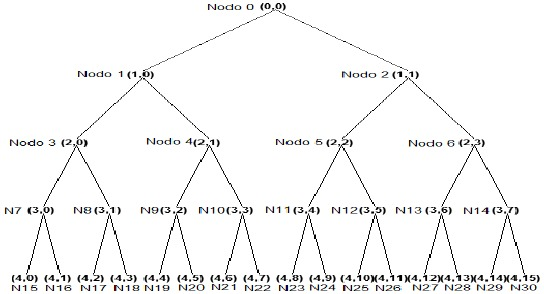

**Figura 1:** *Esquema conceptual del árbol de descomposición iterativa Wavelet mostrando los niveles y nodos generados.*

A diferencia de configuraciones más superficiales, el diseño metodológico de este proyecto implementó una descomposición profunda de **5 niveles**. En la Transformada Wavelet Discreta (DWT), cada nivel aplica un filtrado pasa-bajas y pasa-altas sucesivo sobre la señal, dividiendo la banda de frecuencia a la mitad en cada iteración. Al llegar al quinto nivel, la señal original queda descompuesta en **6 nodos terminales** (un coeficiente de aproximación final y cinco coeficientes de detalle).

Considerando una frecuencia de muestreo ($F_s$) de 160 Hz (frecuencia de Nyquist de 80 Hz) y nivel de descomposición (L) 5, el ancho de banda por nodo es:

$$\Delta f = \frac{f_s}{2^{L+1}} = \frac{160}{2^6} = 2.5 \text{ Hz}$$

Esto permite alinear los nodos exactamente con las bandas de interés aproximadas. No se elige nivel 6 porque el loop por época se vuelve significativamente más lento por haber el doble de nodos :

# Análisis de Nodos Wavelet 

**Configuración Inicial:**
* **Frecuencia de muestreo ($fs$):** 160 Hz
* **Nivel de descomposición:** 5
* **Ancho de banda por nodo ($bw$):** 2.5 Hz
* **Fórmula del centro del nodo:** $Centro = (n + 0.5) \times bw$
* **Cobertura real del nodo:** $Centro \pm 1.25$ Hz (Bloque completo de 2.5 Hz)

# Desglose de Nodos y Cobertura Frecuencial

| Nodo | Frecuencia Centro (Hz) | Cobertura Real (Hz) | Banda Relacionada |
| :---: | :---: | :---: | :---: |
| **Nodo 0** | 1.25 Hz | 0.0 – 2.5 Hz | — |
| **Nodo 1** | 3.75 Hz | 2.5 – 5.0 Hz | — |
| **Nodo 2** | 6.25 Hz | 5.0 – 7.5 Hz | — |
| **Nodo 3** | 8.75 Hz | 7.5 – 10.0 Hz | **Mu** (8–12 Hz) |
| **Nodo 4** | 11.25 Hz | 10.0 – 12.5 Hz | **Mu** (8–12 Hz) |
| **Nodo 5** | 13.75 Hz | 12.5 – 15.0 Hz | **Beta** (13–30 Hz) |
| *...* | *...* | *...* | *Beta (Nodos intermedios 6 al 10)* |
| **Nodo 11**| 28.75 Hz | 27.5 – 30.0 Hz | **Beta** (13–30 Hz) |


# Resumen de Bandas Objetivo

| Banda | Rango Objetivo (Hz) | Nodos Seleccionados | Cobertura Real Total (Hz) |
| :--- | :---: | :---: | :---: |
| **Mu** | 8 – 12 Hz | Nodos 3 y 4 | 7.5 – 12.5 Hz |
| **Beta** | 13 – 30 Hz | Nodos 5 al 11 | 12.5 – 30.0 Hz |

La energía relativa de cada banda se calcula como la suma de energías de los nodos
correspondientes, normalizada por la energía total de la época:

$$E_{\text{banda}}^{rel} = \frac{\sum_{n \in \text{nodos banda}} \sum_k c_n[k]^2}{\sum_{n=0}^{2^L - 1} \sum_k c_n[k]^2}$$

donde $c_n[k]$ son los coeficientes del nodo $n$ en el nivel $L=5$.


### Uso en el proyecto

Se extraen las energías relativas de D3 (beta) y D4 (mu) en C3, Cz y C4. Durante
la imaginación motora ocurre ERD contralateral al lado imaginado, lo que reduce
la energía en las bandas mu y beta en el hemisferio opuesto. La energía wavelet
captura este fenómeno con resolución temporal que la PSD no provee [1][2].

### Implementación en Python

Para la implementación del análisis Wavelet en Python, el procesamiento se basa en el uso de las bibliotecas: NumPy y PyWavelets.
PyWavelets actúa como el núcleo algorítmico del procesamiento, integrando los bancos de filtros matemáticos necesarios para aplicar la transformada (como la descomposición en paquetes de onda o WPT). Es esta última herramienta la que se encarga de iterar sobre los niveles de descomposición configurados, extrayendo sistemáticamente los coeficientes de cada nodo para lograr aislar con precisión las distintas bandas frecuenciales de interés, tales como los ritmos fisiológicos Mu y Beta.

**2.2.2. Índice 2: Índice de Asimetría de Potencia Hemisférica (Brain Symmetry Index - ASI)**

El Índice de Asimetría (ASI) es una métrica neurofisiológica cuantitativa, intrínsecamente normalizada, diseñada para evaluar la diferencia de potencia espectral relativa entre canales homólogos ubicados de forma simétrica sobre la corteza cerebral (por ejemplo, el hemisferio izquierdo frente al derecho). En el contexto de las interfaces cerebro-computadora (BCI), esta métrica aprovecha la dinámica de los ritmos sensoriomotores (SMR), los cuales fluctúan según el estado de activación de la corteza motora primaria (M1). Su formulación matemática estándar se define como:

$$ASI = \frac{P_{\text{izq}} - P_{\text{der}}}{P_{\text{izq}} + P_{\text{der}}}$$

Donde $P_{\text{izq}}$ y $P_{\text{der}}$ representan la potencia espectral absoluta integrada dentro de una banda de frecuencia específica (como Mu o Beta) para los electrodos del hemisferio izquierdo y derecho, respectivamente. Al tratarse de un cociente diferencial y normalizado, el valor del $ASI$ está estrictamente acotado en el intervalo $[-1, 1]$. Esta estructura matemática ofrece una ventaja analítica crucial: actúa como un filtro espacial intrínseco que cancela el ruido de modo común (como derivas de la línea base o artefactos globales no lateralizados), revelando únicamente la dominancia energética hemisférica pura.

Al iniciar la imaginación motora (IM), las neuronas aumentan su excitabilidad y se despolarizan; al dejar de disparar al unísono, las señales se cancelan entre sí, reduciendo la potencia total (ERD). Según Yu et al. [3], este patrón es asimétrico debido a la organización contralateral: la IM de la mano derecha atenúa la potencia en el canal $C3$ (hemisferio izquierdo), mientras que la de la mano izquierda lo hace en $C4$ (hemisferio derecho). El $ASI$ captura esta diferencia: valores negativos indican activación en $C3$ (mano derecha) y valores positivos indican activación en $C4$ (mano izquierda), optimizando la discriminación de características para el Machine Learning.

### Implementación en Python:

La implementación en Python para la extracción del ASI se diseña integrando las librerías **MNE-Python** y **SciPy**, priorizando la robustez en la estimación del espectro. Primero, MNE-Python gestiona la topología espacial de los datos, aislando las épocas (*epochs*) correspondientes a las tareas motoras en los canales $C3$ y $C4$. Seguidamente, se emplea la función de estimación de Densidad Espectral de Potencia (PSD) de SciPy mediante el método de Welch. Esta etapa es crítica: la señal temporal se divide en segmentos superpuestos (*overlapping*), a los cuales se les aplica una ventana de ahusamiento (típicamente una ventana de Hann) antes de calcular su periodograma promediado. Esto reduce drásticamente la varianza de la estimación espectral. Finalmente, la integración de la potencia en las bandas de interés (8–12 Hz y 13–30 Hz) y el cálculo del cociente algebraico se ejecutan mediante operaciones matriciales vectorizadas de **NumPy**, garantizando una ejecución óptima en milisegundos.


**2.2.3. Índice 3: Parámetros de Hjorth**

Estos parámetros constituyen un conjunto de tres descriptores estadísticos que caracterizan la dinámica de una señal de EEG operando exclusivamente en el dominio del tiempo. Su principal innovación metodológica radica en su capacidad para inferir propiedades espectrales fundamentales (como la frecuencia central y el ancho de banda) a partir del análisis geométrico de la amplitud de la señal y de sus derivadas temporales sucesivas. Esta correspondencia, sustentada en el Teorema de Parseval, permite una caracterización profunda de la señal con una complejidad computacional lineal $O(N)$, eludiendo el alto costo $O(N \log N)$ de las transformaciones frecuenciales tradicionales. Los parámetros se definen formalmente como [4]:

* Actividad (Activity): Mide la dispersión de la amplitud de la señal respecto a su media, representando físicamente la potencia espectral total de la época analizada. Corresponde a la varianza de la señal temporal:
$$\text{Actividad} = \text{Var}(x(t))$$

* Movilidad (Mobility): Actúa como un estimador de la frecuencia media predominante en la señal (el centroide del espectro de potencia). Geométricamente, representa la proporción de la pendiente típica de la señal (velocidad) respecto a su amplitud típica. Se define como:
$$\text{Movilidad} = \sqrt{\frac{\text{Var}(x'(t))}{\text{Var}(x(t))}}$$

* Complejidad (Complexity): Estima el ancho de banda y la desviación de la señal respecto a un modelo armónico simple. Una onda senoidal pura posee una complejidad de 1; valores superiores indican la presencia de múltiples componentes frecuenciales (armónicos o ruido). Se calcula comparando la movilidad de la primera derivada (cambio en la pendiente o aceleración) con la movilidad de la señal original:
$$\text{Complejidad} = \frac{\text{Movilidad}(x'(t))}{\text{Movilidad}(x(t))}$$

La transición del estado de reposo a la imaginación motora (ERD) induce alteraciones morfológicas drásticas en las trazas de $C3$ y $C4$. Al iniciarse la tarea cognitiva, la *Actividad* experimenta una atenuación repentina, reflejando la caída de potencia característica de los ritmos Mu y Beta. Paralelamente, la desincronización neuronal fragmenta los ritmos basales lentos, sustituyéndolos por oscilaciones más rápidas e irregulares; este fenómeno es capturado inmediatamente por un incremento en la *Movilidad* (desplazamiento hacia frecuencias superiores) y en la *Complejidad* (pérdida de la estructura armónica y aumento de la dispersión espectral). Esta triada proporciona al clasificador descriptores temporales ortogonales a la información de asimetría de potencia, enriqueciendo el espacio de características.

### Implementación en Python:

Para asegurar la viabilidad del procesamiento en tiempo real (requisito fundamental en sistemas BCI), la extracción de estos descriptores se delega a **MNE-Features** o al uso optimizado de **NumPy**. En una implementación pura con NumPy, el procedimiento consiste en calcular la primera y segunda derivada discreta de la serie temporal mediante diferencias finitas (`numpy.diff`), simulando la velocidad y aceleración de la señal electromagnética. Posteriormente, se aplica la función de varianza (`numpy.var`) sobre estos vectores derivados para resolver el sistema de ecuaciones algebraicas de Hjorth. Al evitar el paso a la transformada de Fourier, este bloque algorítmico minimiza drásticamente el consumo de memoria y los tiempos de latencia del sistema, haciendo que la extracción de características sea sumamente ágil.








# **2.3 Técnicas de división de datos y algoritmos de Clasificación Supervisada**

La evaluación del rendimiento de un modelo de Machine Learning requiere metodologías rigurosas para estimar su capacidad de generalización sobre datos no observados, mitigando riesgos como el sobreajuste (*overfitting*). Para ello, se emplean técnicas de particionamiento iterativo.

**2.3.1. K-Fold**

La validación cruzada *K-Fold* es una técnica estadística de remuestreo que evalúa el rendimiento de un modelo de forma exhaustiva. El procedimiento consiste en dividir aleatoriamente el conjunto de datos completo en $k$ subconjuntos (o *folds*) mutuamente excluyentes y de tamaño aproximadamente igual. El proceso de entrenamiento y evaluación se repite $k$ veces de forma iterativa. En cada iteración, un *fold* diferente se retiene como conjunto de prueba (*test set*), mientras que los $k-1$ subconjuntos restantes se concatenan para formar el conjunto de entrenamiento (*training set*). El rendimiento final del modelo se reporta como el promedio de las métricas obtenidas en las $k$ iteraciones. Esta metodología garantiza que cada observación del conjunto de datos original se utilice exactamente una vez para validación y $k-1$ veces para entrenamiento.

**2.3.1.1 Stratified K-Fold**

El *Stratified K-Fold* es una evolución metodológica del K-Fold estándar, diseñada específicamente para abordar problemas de clasificación donde existe un desbalance en la distribución de las clases (como es común en el registro de señales biomédicas y paradigmas BCI). Mientras que el K-Fold tradicional divide los datos de forma puramente aleatoria, la versión estratificada impone una restricción probabilística: garantiza que la proporción relativa de cada clase presente en el conjunto de datos original se preserve idénticamente dentro de cada uno de los $k$ *folds*. Matemáticamente, si una clase $c$ representa una fracción $p_c$ del total de datos, cada *fold* contendrá exactamente esa misma fracción $p_c$ de muestras de la clase $c$. Esto evita sesgos de muestreo en iteraciones particulares (por ejemplo, entrenar un modelo sin suficientes muestras de una clase minoritaria), asegurando que las métricas de rendimiento sean estables, representativas y fiables a lo largo de toda la validación.


**2.3.2 Algoritmos de Clasificación Supervisada**

Para discriminar los patrones neurofisiológicos asociados a la imaginación motora, se evalúan algoritmos que varían en su complejidad y base matemática, yendo desde separadores geométricos hasta ensambles de árboles y modelos conexionistas.

**2.3.2.1 Máquinas de Vectores de Soporte (SVM)**

Las Máquinas de Vectores de Soporte (*Support Vector Machines* o SVM) son modelos robustos de aprendizaje supervisado fundamentados en la teoría del aprendizaje estadístico. El objetivo principal de una SVM es encontrar el hiperplano óptimo que separe las distintas clases en el espacio de características, maximizando el margen geométrico (la distancia) entre el hiperplano y las muestras más cercanas de cada clase, denominadas "vectores de soporte". 

La ecuación matemática que define un hiperplano lineal es:
$$w^T x + b = 0$$

Donde $w$ es el vector de pesos que define la orientación del plano, $x$ es el vector de características y $b$ es el sesgo. Para problemas biomédicos donde los datos (como los índices de Hjorth o ASI) no son linealmente separables, la SVM emplea el "truco del kernel" (*Kernel Trick*). Funciones como el Kernel de Base Radial (RBF) mapean implícitamente los datos de entrada hacia un espacio de mayor dimensionalidad donde la separación lineal es factible, sin incurrir en el alto costo computacional de transformar explícitamente las coordenadas.

**2.3.2.2 Extreme Gradient Boosting (XGBoost)**

XGBoost es un algoritmo avanzado de aprendizaje en ensamble (*ensemble learning*) basado en la técnica de *Gradient Boosting*. A diferencia de entrenar un único modelo complejo, XGBoost entrena una secuencia de modelos débiles (típicamente árboles de decisión poco profundos). Su funcionamiento es iterativo: cada nuevo árbol se entrena específicamente para predecir y corregir los errores residuales (el gradiente de la función de pérdida) cometidos por el conjunto de árboles anteriores. 

La predicción final $\hat{y}_i$ para una instancia $x_i$ es la suma de las predicciones de los $K$ árboles:
$$\hat{y}_i = \sum_{k=1}^K f_k(x_i)$$

Lo que hace "Extremo" a XGBoost es su optimización algorítmica de bajo nivel: incorpora rutinas de regularización L1 (Lasso) y L2 (Ridge) en su función objetivo para penalizar la complejidad de los árboles y prevenir el sobreajuste. Además, maneja internamente datos faltantes y paraleliza la construcción de los nodos, lo que lo hace excepcionalmente rápido, preciso y resistente al ruido intrínseco de las señales de EEG.

**2.3.2.3 Redes Neuronales Artificiales (ANN)**

Las Redes Neuronales Artificiales (ANN), y específicamente el Perceptrón Multicapa (MLP), son modelos computacionales inspirados en la topología funcional del sistema nervioso biológico. Una red estándar se compone de múltiples capas de nodos iterativos: una capa de entrada (que recibe las dimensiones del vector de características), una o más capas ocultas, y una capa de salida (que emite las probabilidades de pertenencia a las distintas clases motoras).

La dinámica de procesamiento de una neurona individual está regida por la suma ponderada de sus entradas más un sesgo, seguida de una transformación no lineal a través de una función de activación $g$:
$$a = g(W^T x + b)$$

Las capas ocultas suelen utilizar funciones de activación como ReLU (*Rectified Linear Unit*), mientras que la capa de salida para un problema multiclase emplea la función Softmax, la cual normaliza las salidas en una distribución de probabilidad. El aprendizaje se lleva a cabo mediante el algoritmo de propagación hacia atrás (*Backpropagation*), el cual utiliza el descenso del gradiente para actualizar iterativamente la matriz de pesos $W$ y los sesgos $b$, minimizando la función de pérdida de entropía cruzada. Esta arquitectura permite modelar representaciones abstractas y relaciones altamente no lineales entre los parámetros temporales, espaciales y frecuenciales extraídos del EEG.

**3.PLAN DE ANÁLISIS**
---

## **3.1 Condiciones a clasificar**

Con base en el entregable 1 (epocas de C3 y C4) y los índices adicionales consultados, el análisis
se orienta a discriminar tres condiciones:

| Etiqueta | Condición |
|----------|-----------|
| 0 | Reposo (baseline) |
| 1 | Imaginación motora mano izquierda |
| 2 | Imaginación motora mano derecha |

Los canales de interés son **C3 y C4**, electrodos sensorimotores primarios sobre
la corteza motora contralateral, seleccionados por ser los más discriminativos en
el análisis estadístico del proyecto 1.

## **3.2 Extracción de características**

Para cada época de 4 segundos (640 muestras, fs = 160 Hz) en los canales C3 y C4
se extraen cuatro grupos de características, para un total de **16 features por época**:

### Grupo 1: Densidad espectral de potencia normalizada (Proyecto 1)
Potencia relativa en bandas mu (8–12 Hz) y beta (13–30 Hz), calculada con Welch
y normalizada respecto al rango 0.5–40 Hz. Exportada desde el Proyecto 1.

- mu_C3, mu_C4, beta_C3, beta_C4 → **4 features**

### Grupo 2: Energía Wavelet por Paquetes (db4, level=5)
Captura cómo varía la potencia a lo largo del tiempo dentro de cada época,
complementando la PSD que promedia sobre toda la ventana temporal. Se extraen
las energías relativas en las bandas mu y beta en C3 y C4.

- wavelet_mu_C3, wavelet_mu_C4, wavelet_beta_C3, wavelet_beta_C4 → **4 features**

### Grupo 3: Índice de Asimetría Hemisférica (ASI)
Cuantifica la diferencia de potencia entre C3 y C4 en cada banda. Debido a la
organización contralateral del sistema motor, las condiciones de imaginación
generan valores de signo opuesto: ASI < 0 para mano derecha (ERD en C3) y
ASI > 0 para mano izquierda (ERD en C4), con valores cercanos a cero en reposo.

- asi_mu, asi_beta → **2 features**

### Grupo 4: Parámetros de Hjorth
Descriptores temporales que caracterizan la amplitud, frecuencia media y
complejidad de la dinámica cortical sin requerir transformaciones frecuenciales,
complementando los índices espectrales.

- hjorth_act_C3, hjorth_act_C4 → amplitud de la señal
- hjorth_mob_C3, hjorth_mob_C4 → frecuencia media dominante
- hjorth_comp_C3, hjorth_comp_C4 → irregularidad respecto a onda sinusoidal pura

→ **6 features**

## **3.3 Análisis estadístico descriptivo**

Antes de la clasificación se realiza un análisis exploratorio para verificar
que los índices discriminan entre condiciones. Se calculan las siguientes
medidas descriptivas por condición (0, 1, 2) y canal para cada feature:

- **Media y desviación estándar:** resumen de la tendencia central y dispersión
  de cada índice por condición. Permiten identificar si las condiciones se
  separan en valor promedio.
- **Mediana y rango intercuartílico (IQR):** medidas robustas frente a outliers,
  más adecuadas para señales EEG cuya distribución suele ser no normal.
- **Mínimo y máximo:** identifican el rango de variación y posibles valores
  extremos que podrían afectar el clasificador.

Con base en estas medidas se generan las siguientes gráficas:

- **Boxplots** por condición para cada feature: muestran mediana, IQR y outliers simultáneamente, facilitando la comparación visual entre las tres condiciones.
- **Violin plots** para el ASI: la distribución bimodal esperada entre imag_izq
e imag_der (valores de signo opuesto) se visualiza mejor con violin que con
boxplot.
- **Heatmap de correlación** entre los 16 features: identifica redundancia entre índices. Features con |r| > 0.9 se evalúan para posible eliminación antes
de la clasificación, evitando que información redundante afecte el modelo.

## **3.4 Análisis exploratorio de los nuevos índices**

### 3.4.1 Distribución por condición
Se espera que:
- La energía wavelet mu y beta sea menor en imaginación motora que en reposo,
  reflejando ERD
- El ASI tenga signo opuesto para imag_izq vs imag_der, con valores cercanos
  a cero en reposo
- La movilidad y actividad de Hjorth difieran entre reposo e imaginación motora

### 3.4.2 Correlación entre features
Features altamente correlacionados (se tomarán como |r| > 0.8) se evalúan para posible eliminación antes de la clasificación, para reducir redundancia sin perder información discriminativa.

## **3.5 Selección de prueba estadística**

**3.5.1. Paso 1: Verificación de normalidad:**
Se aplica la prueba de D'Agostino-Pearson por condición y feature, que combina
asimetría y curtosis en un estadístico chi-cuadrado y es válida para cualquier
tamaño de muestra, permitiendo usar todas las épocas disponibles.
Si p > 0.05 en todas las condiciones → prueba paramétrica. Si p ≤ 0.05 en al
menos una condición → no paramétrica.

**3.5.2. Paso 2a: Comparación entre las 3 condiciones (análisis neurofisiológico):**
Objetivo: verificar que los features detectan diferencias generales entre
reposo e imaginación motora.

| Caso | Prueba principal | Post-hoc |
|------|-----------------|----------|
| Normal | ANOVA de una vía | Tukey HSD |
| No normal | Kruskal-Wallis | Dunn con corrección Bonferroni |

Cuando Kruskal-Wallis rechaza H0, se aplica Dunn con Bonferroni para
identificar qué pares de condiciones difieren significativamente:

| Par | Interpretación si es significativo |
|-----|-----------------------------------|
| Reposo vs Imag. Izq | El índice discrimina reposo de imaginación izquierda |
| Reposo vs Imag. Der | El índice discrimina reposo de imaginación derecha |
| Imag. Izq vs Imag. Der | El índice discrimina entre las dos manos |

**3.5.3. Paso 2b: Comparación entre las 2 condiciones de imaginación (criterio de selección para BCI):**
Objetivo: identificar qué features distinguen entre imaginación izquierda
e imaginación derecha, más relevante para distinguir entre el IM.

| Caso | Prueba |
|------|--------|
| No normal | Mann-Whitney U (two-sided) |

**3.5.4 Criterio de selección de features para el clasificador:**
Se usa el resultado de Mann-Whitney U (imag_izq vs imag_der) como criterio
principal de selección, excluyendo el reposo deliberadamente. Esto se justifica
porque el reposo genera una diferencia muy grande con cualquier condición de
imaginación, lo que haría que casi todos los features parecieran
discriminativos aunque en realidad no distingan entre las dos manos. Sin embargo, del análisis de los dos grupos se seleccionan 2 indicadores más, los cuales no presenten alta correlación con otros.

Los features se seleccionan en orden de p-value ascendente (menor p = mayor
evidencia de discriminación entre manos).

Kruskal-Wallis se usa como análisis complementario para confirmar el ERD (por ejemplo, en el reposo se da reducción de potencia en las bandas asociadas)
neurofisiológico esperado, no como criterio de selección.

Nivel de significancia: α = 0.05 en ambas pruebas.
## **3.6 Hipótesis estadísticas**

Para cada feature $f$ en cada canal $ch$:

**H0:** La distribución de $f$ es igual en las tres condiciones
(reposo, imag_izq, imag_der).

Donde $f$ representa cada feature
por canal para índices uniCanal (PSD, Wavelet, Hjorth) o el índice
combinado entre canales para el ASI.

**H1:** Al menos una condición difiere significativamente de las demás en $f$.

### Hipótesis específicas de interés neurofisiológico

**Hipótesis 2: Energía wavelet mu:**
- H0: La energía wavelet en banda mu es igual en las tres condiciones.
- H1: La energía wavelet en banda mu difiere entre condiciones, esperándose
  mayor energía en reposo que en imaginación motora, reflejando ERD contralateral.

**Hipótesis 3: Energía wavelet beta:**
- H0: La energía wavelet en banda beta es igual en las tres condiciones.
- H1: La energía wavelet en banda beta difiere entre condiciones, esperándose
  desincronización durante imaginación motora respecto al reposo.

**Hipótesis 4: ASI:**
- H0: El ASI en bandas mu y beta es igual en las tres condiciones.
- H1: El ASI difiere entre condiciones, esperándose valores negativos para
  imaginación mano derecha (ERD en C3) y positivos para imaginación mano
  izquierda (ERD en C4), con valores cercanos a cero en reposo.

**Hipótesis 5: Parámetros de Hjorth:**
- H0: Actividad, movilidad y complejidad son iguales en las tres condiciones.
- H1: Al menos uno de los parámetros difiere entre reposo e imaginación motora,
  reflejando cambios en la dinámica cortical asociados al control motor voluntario.

**Hipótesis 6: Lateralización (izq vs der):**
- H0: La distribución de cada feature es igual entre imaginación izquierda 
  e imaginación derecha.
- H1: Al menos un feature difiere entre las dos condiciones de imaginación.

## **3.7 Estrategia de clasificación**

### 3.7.1 Preprocesamiento previo al clasificador
- Verificación de balance de clases (0: 3240, 1: 2439, 2: 2400 épocas)
- StandardScaler sobre las features dentro de cada fold
  (fit en train, transform en test)
- `class_weight='balanced'` para compensar el desbalance entre clases

### 3.7.2 Estrategia de entrenamiento y evaluación

Se implementan dos estrategias de particionamiento:

- **KFold (k=5):** requerido por el enunciado. Divide los datos en 5
  folds sin controlar la distribución de clases. Cada fold (grupo) se usa una
  vez como conjunto de validación mientras los 4 restantes forman el
  conjunto de entrenamiento.

- **StratifiedKFold (k=5):** mejora metodológica que garantiza que
  cada fold mantiene la misma proporción de clases que el dataset
  completo, evitando folds con distribuciones desbalanceadas.

Se reportan accuracy, F1-score macro y matriz de confusión
promediados sobre los 5 folds.

### **3.8 Clasificadores**
Se implementan y comparan cinco clasificadores:

- **Tres arquitecturas de red neuronal** (consultadas y justificadas previamente)
- **Máquina de Soporte Vectorial (SVM)** 
- **Extreme Gradient Boosting (XGBoost)** 

### 3.8.1 Selección de features para clasificación
Se compara el rendimiento con el conjunto completo de 16 features versus el
subconjunto de features que mostraron diferencias significativas en el análisis
estadístico, para evaluar si la reducción de dimensionalidad mejora la clasificación.


### **3.9 Flujo de datos entre Proyecto 1 y Proyecto 2**

### 3.9.1 Exportaciones del Proyecto 1

Se tendran una serie de archivos que permitiran el flujo de datos entre ambos proyectos, estos archivos contendran información clave que sear usada para trabajar las señales en el presente proyecto

**`df_proyecto2_completo.csv`**
Contiene la PSD normalizada (mu y beta en C3, Cz, C4) calculada con el método
de Welch, una fila por época, con etiquetas de sujeto y tarea:
- 0 = reposo
- 1 = imaginación motora mano izquierda
- 2 = imaginación motora mano derecha

**`epocas_c3.npy` y `epocas_c4.npy`**
Contienen la señal temporal de los canales C3 y C4 ya filtrada (Butterworth
orden 7, HP 0.5 Hz + LP 40 Hz, fase cero con `sosfiltfilt`) y segmentada en
ventanas de 4 s (640 muestras a 160 Hz), en el mismo orden fila a fila que
el CSV.

### 3.9.2 Procesamiento en el Proyecto 2

Sobre `epocas_c3.npy` y `epocas_c4.npy` se calculan tres índices nuevos
época por época:

| Índice | Descripción | Features generados |
|--------|-------------|-------------------|
| Energía Wavelet por Paquetes (WPT, db4, level=5) | Energía relativa en nodos 3–4 ≈ mu (7.5–12.5 Hz) y nodos 5–11 ≈ beta (12.5–27.5 Hz) | `wavelet_mu_C3`, `wavelet_mu_C4`, `wavelet_beta_C3`, `wavelet_beta_C4` |
| ASI | Asimetría de potencia espectral entre C3 y C4 en bandas mu y beta | `asi_mu`, `asi_beta` |
| Hjorth | Actividad, movilidad y complejidad en dominio temporal | `hjorth_act_C3/C4`, `hjorth_mob_C3/C4`, `hjorth_comp_C3/C4` |

Los 12 features nuevos se unen al CSV del Proyecto 1 por posición (fila *i*
del CSV = época *i* de los `.npy`), dando el DataFrame final con **16 features

---

**4. RESULTADOS Y DISCUSION**
--
## **4.1 Análisis estádistico descriptivo**
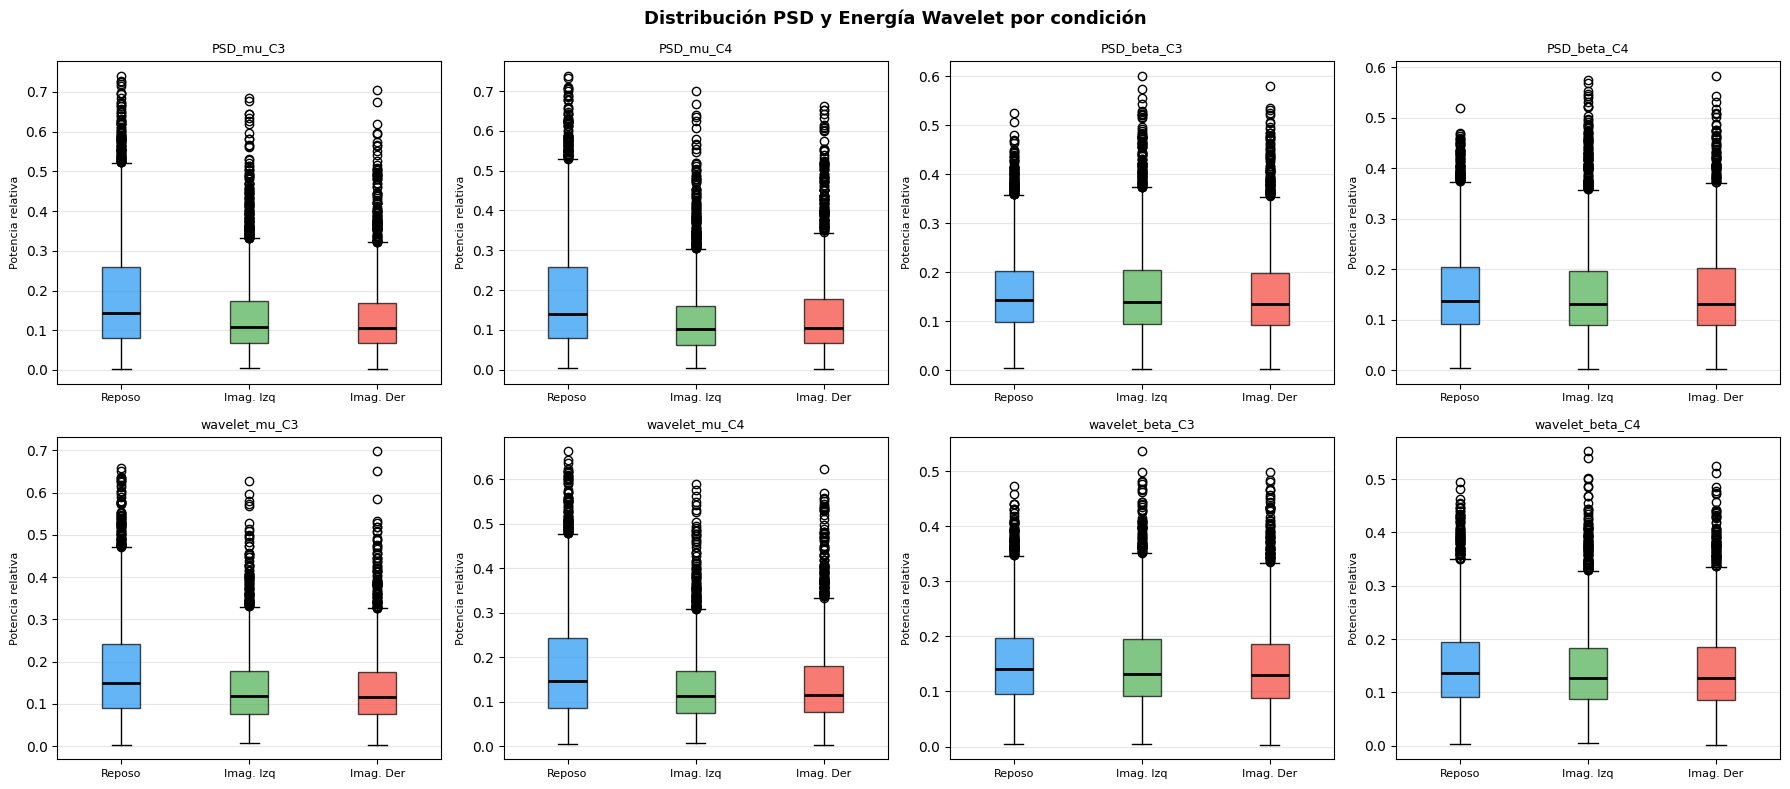

**Figura 1. PSD y Energia de Wavelet por condicion.**


En la figura 1, es posible observar la distribución de la Densidad Espectral de Potencia (Welch) y la Energía Relativa Wavelet en los canales C3 y C4, categorizada por banda frecuencial (Mu y Beta) y condición experimental.

La gráfica presenta ocho boxplots que comparan la extracción de características frecuenciales (PSD en la fila superior) y temporo-frecuenciales (Energía Wavelet en la fila inferior) sobre los canales motores primarios C3 y C4.

De la gráfica es posible observar las siguientes características:

* Caída de potencia frente al reposo: En los boxplots, la condición de "Reposo" exhibe consistentemente una mediana superior y un Rango Intercuartílico más amplio en comparación con las dos condiciones de imaginación motora. Este efecto es notablemente más pronunciado en la banda Mu que en la banda Beta.


* Superposición de clases activas: Al comparar exclusivamente las condiciones de "Imag. Izq" e "Imag. Der", se observa una superposición casi total de sus cajas y bigotes en el análisis unicanal. Sus medianas se ubican en niveles de potencia relativa muy similares, dificultando la separación lineal directa a simple vista.


* Distribución de los datos: Todas las características extraídas presentan una marcada asimetría positiva (sesgo a la derecha), evidenciada por la densa concentración de valores atípicos (outliers, representados por los círculos negros) por encima del bigote superior.


* Equivalencia de métodos: Las distribuciones obtenidas mediante el cálculo de la PSD (Welch) son morfológica y estadísticamente análogas a las obtenidas mediante el cálculo de la Energía por Paquetes Wavelet.

Gracias a los resultados obtenidos en la gráfical, es posible confirmar la presencia neurofisiológica de la Desincronización Relacionada con Eventos (ERD) durante las tareas de imaginación motora. Específicamente, la caída significativa de la potencia relativa en las bandas Mu y Beta frente a los niveles basales del estado de reposo refleja cómo las poblaciones neuronales de la corteza sensoriomotora se desincronizan al iniciar la actividad cognitiva. Asimismo, la alta similitud morfológica entre las distribuciones obtenidas mediante la densidad espectral (Welch) y la energía Wavelet indica que ambos enfoques matemáticos capturan de manera consistente esta atenuación energética global en los canales C3 y C4. Sin embargo, el evidente solapamiento intercuartílico entre la imaginación izquierda y derecha, sumado a la marcada asimetría positiva y la alta densidad de valores atípicos (outliers), sugiere que a nivel estrictamente unicanal el ERD se manifiesta de manera difusa. Esta superposición demuestra que la magnitud absoluta de la potencia en un electrodo individual es suficiente para distinguir el reposo de la actividad motora, pero resulta insuficiente por sí sola para discriminar de forma directa la lateralidad del movimiento imaginado.


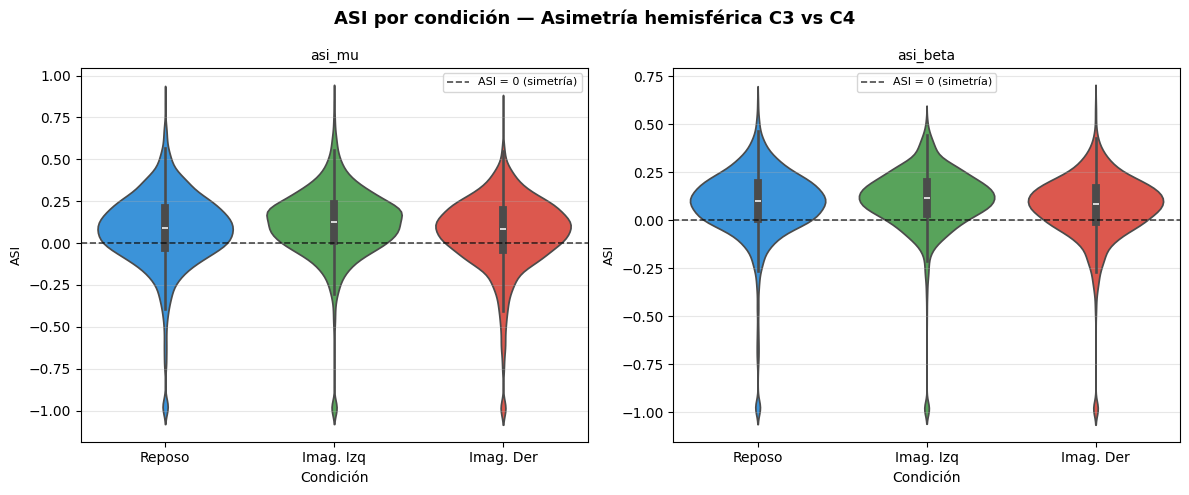

**Figura 2. Distribución de densidad del Indice ASI en las bandas Mu y Beta**

En la figura 2, es posible observar la distribución de densidad del Índice de Asimetría Hemisférica (ASI) en las bandas Mu y Beta según la condición experimenta.
La gráfica presenta los resultados en forma de diagramas de violín para representar la distribución de probabilidad subyacente del Índice de Asimetría (ASI) en los canales C3 y C4, complementada con un diagrama de caja interno. La línea punteada horizontal marca el nivel de simetría perfecta (ASI = 0).

En la gráfica es posible observan las siguientes características:


* Desplazamiento de las medianas por clase: En la banda Mu (asi_mu), la condición de imaginación izquierda desplaza el "cuerpo" del violín y su mediana hacia valores positivos (por encima de 0). Por el contrario, la imaginación derecha concentra su densidad más hacia abajo, con una mediana inferior a la de la mano izquierda, acercándose o cruzando la línea de simetría hacia valores negativos.


* Comportamiento del reposo: La condición de reposo tiende a agruparse cerca de la línea central de simetría (ASI = 0), aunque exhibe un ligero sesgo hacia valores positivos.

* Diferencia entre bandas: Las diferencias distribucionales entre las condiciones de imaginación izquierda y derecha son visualmente más pronunciadas y separables en la banda Mu que en la banda Beta (asi_beta), donde las tres clases muestran un mayor solapamiento en sus densidades centrales.

* Alta variabilidad: Las tres condiciones presentan colas verticales muy alargadas que se extienden hacia los límites del índice (-1.00), lo que indica la presencia de épocas puntuales con asimetrías hemisféricas extremas.


Los resultados obtenidos a través del ASI confirman que esta métrica logra capturar la lateralización de la actividad cortical que permanecía oculta en el análisis unicanal. El comportamiento observado en la banda Mu es congruente con el principio de control motor contralateral: durante la imaginación de la mano izquierda, la Desincronización Relacionada con Eventos (ERD) ocurre predominantemente en el hemisferio derecho (canal C4), lo que disminuye su potencia respecto a C3 y empuja matemáticamente el ASI hacia valores positivos. De forma inversa, la imaginación de la mano derecha provoca un ERD en el hemisferio izquierdo (C3), reduciendo el numerador de la ecuación y desplazando la distribución hacia valores negativos. El hecho de que este efecto cruzado sea mucho más claro en la banda Mu reafirma que este ritmo es el indicador más sensible para discriminar espacialmente la intención motora. Por otro lado, la presencia de colas largas y el ligero solapamiento en la banda Beta evidencian la alta variabilidad natural y el ruido inherente a las señales de EEG, corroborando que, aunque el ASI extrae información espacial valiosa, se requiere su combinación con otras métricas en un modelo de Machine Learning multivariable para lograr una clasificación completamente precisa.


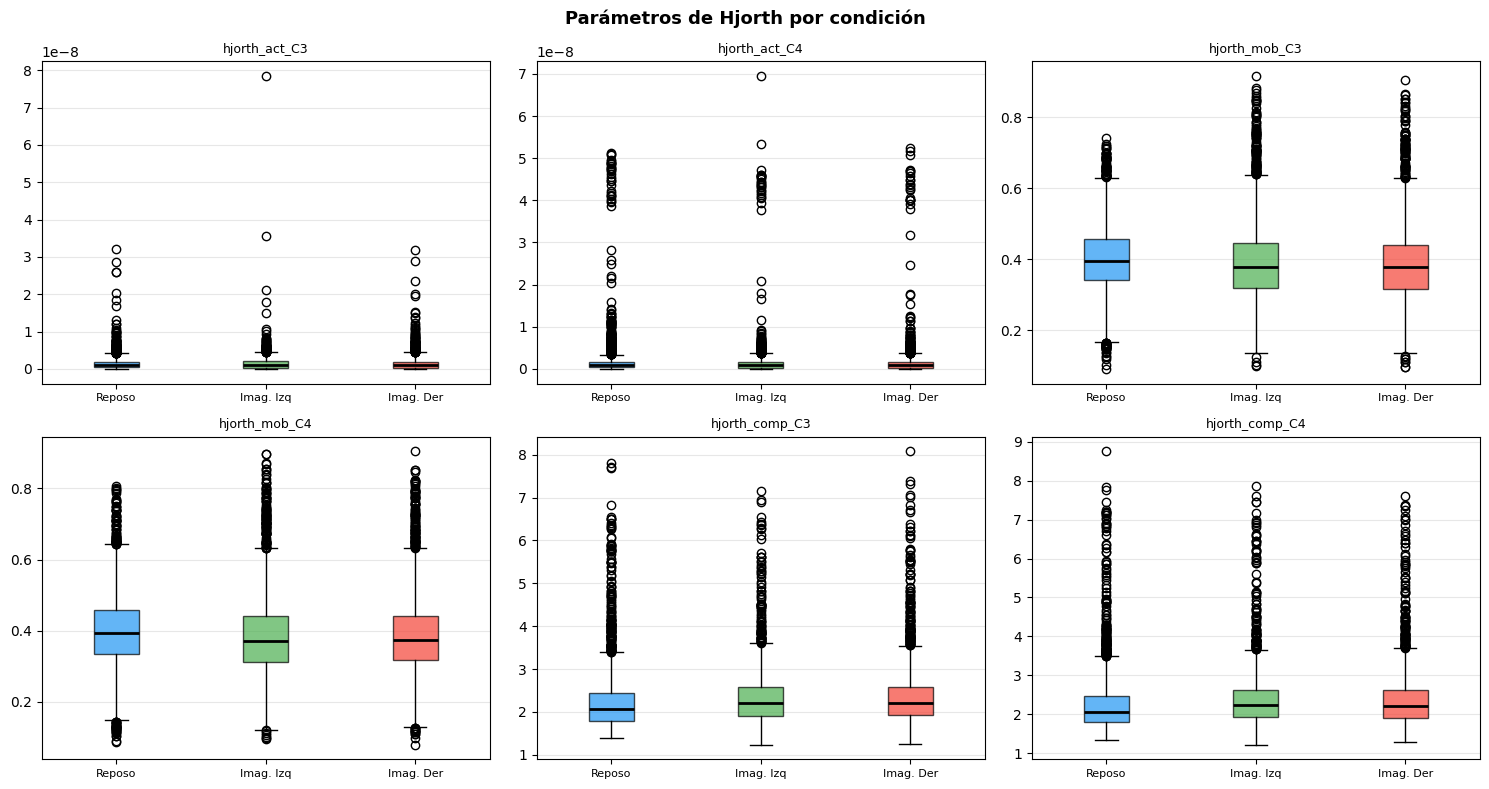

**Figura 3. Distribución de parametros de Hjorth en canales C3 y C4**

En la figura 3, es posible observar la distribución de los parámetros temporales de Hjorth (Actividad, Movilidad y Complejidad) en los canales C3 y C4 según la condición experimental.

La gráfica presenta seis boxplots que ilustran la distribución de los tres descriptores de Hjorth calculados sobre las épocas de los canales motores.
A partir de los datos observados en la gráfica, es posible identificar las siguientes características:

* Actividad (hjorth_act): Presenta valores extremadamente bajos (en una escala de 1x10^-8) con los boxplots fuertemente comprimidos cerca del cero. Se observa una gran cantidad de valores atípicos superiores (outliers) que estiran el eje Y en todas las condiciones, haciendo que se visualicen de manera mas facil las diferencias entre las medianas de reposo e imaginación.


* Movilidad (hjorth_mob): Las distribuciones muestran medianas en torno a 0.4. La condición de reposo exhibe una mediana ligeramente superior o equivalente a las condiciones de imaginación motora. Nuevamente, existe una fuerte superposición intercuartílica entre las tres clases y múltiples atípicos superiores.


* Complejidad (hjorth_comp): Se evidencia un patrón inverso al reposo en comparación con otras métricas. Las condiciones de imaginación izquierda y derecha muestran medianas (alrededor de 2.2) y rangos intercuartílicos ligeramente superiores a la condición de reposo (mediana cercana a 2.0).


* Solapamiento inter-clase: Al igual que en las características frecuenciales unicanal evaluadas previamente, no existe una separación visual clara entre las distribuciones de imaginación izquierda e imaginación derecha en ninguno de los tres parámetros.

El análisis de los parámetros de Hjorth complementa los hallazgos espectrales al confirmar los cambios en la dinámica temporal del EEG durante la tarea cognitiva. El comportamiento del parámetro de Complejidad es el hallazgo neurofisiológico más revelador de esta gráfica: dado que este índice mide la desviación de una señal respecto a una onda sinusoidal pura, su incremento durante la imaginación motora refleja de forma directa la desincronización neuronal (ERD). En estado de reposo, el ritmo Mu dominante genera oscilaciones más sincrónicas y armónicas (menor complejidad); sin embargo, al activar la intención motora, la red neuronal se desincroniza, fragmentando el ritmo basal y produciendo una traza temporal mucho más irregular e impredecible.

Por otro lado, la extrema compresión y asimetría en la Actividad (la cual representa la varianza o potencia total de la señal) evidencia la alta variabilidad natural de las amplitudes del EEG y las diferencias de impedancia inter-sujeto. Finalmente, el alto grado de solapamiento entre las clases activas en los tres descriptores refuerza la premisa de que los análisis temporales de electrodos aislados no contienen suficiente resolución espacial para discriminar la lateralidad del movimiento. Esto ratifica que los parámetros de Hjorth deben actuar como atributos complementarios —aportando información sobre la irregularidad de la onda (Complejidad)— dentro de los vectores de características que alimentarán los algoritmos de Machine Learning multivariable.


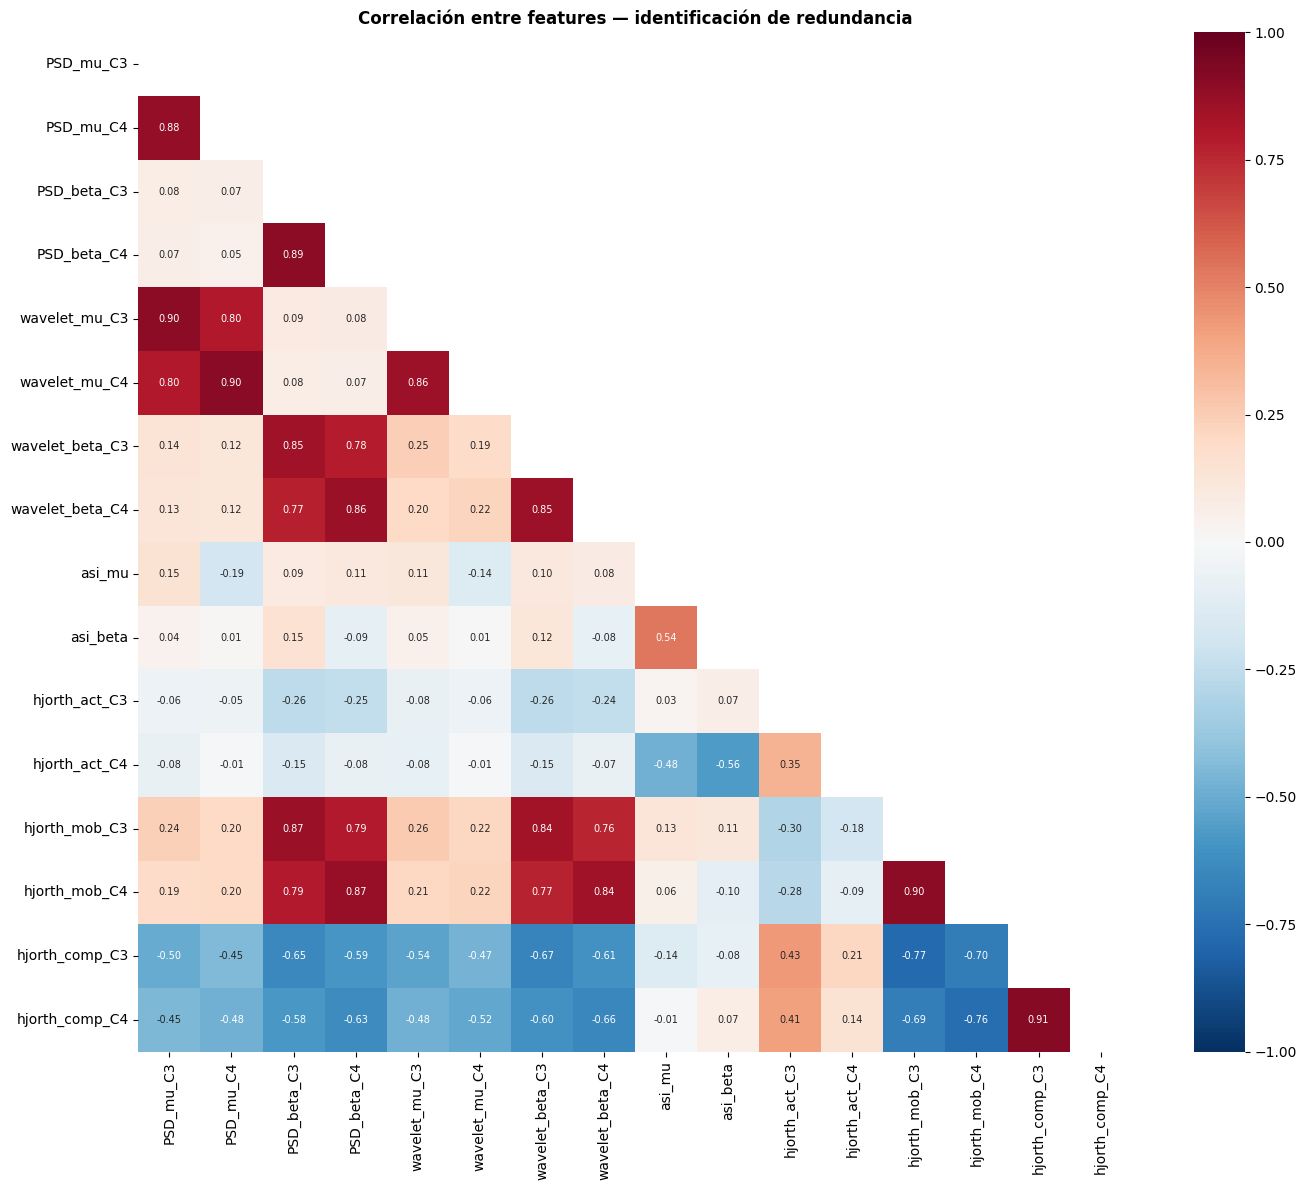

**Figura 4. Mapa de correlación para 16 descriptores**

### Resultados Estadísticos de las Características Extraídas

**Paso 1: Verificación de normalidad (D'Agostino-Pearson)**
Al evaluar la distribución de las muestras combinando asimetría y curtosis, se determinó que **ninguna (0)** de las 16 características presenta una distribución normal. Por lo tanto, se justifica metodológicamente el uso exclusivo de **pruebas estadísticas no paramétricas**.

**Paso 2a: Prueba de Kruskal-Wallis (Reposo vs. Imag. Izquierda vs. Imag. Derecha)**
Esta prueba evalúa si existen diferencias significativas entre las tres condiciones experimentales en general. 

| Característica | Estadístico | Valor p (*p-value*) | Significativo (p < 0.05) |
| :--- | :--- | :--- | :--- |
| **PSD_mu_C4** | 271.11 | 0.0000 | **Sí** |
| **PSD_mu_C3** | 266.87 | 0.0000 | **Sí** |
| **wavelet_mu_C3** | 228.14 | 0.0000 | **Sí** |
| **wavelet_mu_C4** | 223.69 | 0.0000 | **Sí** |
| **hjorth_comp_C3** | 152.69 | 0.0000 | **Sí** |
| **hjorth_comp_C4** | 139.34 | 0.0000 | **Sí** |
| **asi_mu** | 103.11 | 0.0000 | **Sí** |
| **asi_beta** | 78.18 | 0.0000 | **Sí** |
| **hjorth_act_C3** | 62.03 | 0.0000 | **Sí** |
| **hjorth_act_C4** | 58.91 | 0.0000 | **Sí** |
| **hjorth_mob_C3** | 55.90 | 0.0000 | **Sí** |
| **hjorth_mob_C4** | 53.43 | 0.0000 | **Sí** |
| **wavelet_beta_C3** | 20.81 | 0.00003 | **Sí** |
| **wavelet_beta_C4** | 15.48 | 0.00043 | **Sí** |
| **PSD_beta_C3** | 7.69 | 0.02129 | **Sí** |
| **PSD_beta_C4** | 3.04 | 0.21843 | No |

*Nota: Se procedió a guardar el análisis Post-hoc de Dunn para observar las diferencias específicas entre pares de clases.*

**Paso 2b: Prueba U de Mann-Whitney (Imag. Izquierda vs. Imag. Derecha)**
Esta prueba responde a la pregunta más crítica para la Interfaz Cerebro-Computadora (BCI): ¿Tiene el índice la capacidad estadística para distinguir la lateralidad del movimiento?

| Característica | Estadístico | Valor p (*p-value*) | Significativo (p < 0.05) |
| :--- | :--- | :--- | :--- |
| **asi_mu** | 3403241.0 | 0.0000 | **Sí** |
| **asi_beta** | 3361246.0 | 0.0000 | **Sí** |
| **PSD_mu_C4** | 2791255.0 | 0.00527 | **Sí** |
| **wavelet_mu_C4** | 2810928.0 | 0.01709 | **Sí** |
| **hjorth_comp_C4** | 3021920.0 | 0.05027 | No |
| **hjorth_comp_C3** | 2843814.0 | 0.08765 | No |
| **PSD_beta_C3** | 3007108.0 | 0.09837 | No |
| **wavelet_beta_C3** | 3005701.0 | 0.10441 | No |
| **PSD_mu_C3** | 2996910.0 | 0.14905 | No |
| **hjorth_mob_C4** | 2859126.0 | 0.16369 | No |
| **hjorth_act_C4** | 2865514.0 | 0.20720 | No |
| **hjorth_mob_C3** | 2957533.0 | 0.52706 | No |
| **wavelet_mu_C3** | 2945600.0 | 0.69882 | No |
| **wavelet_beta_C4** | 2936594.0 | 0.84026 | No |
| **hjorth_act_C3** | 2934642.0 | 0.87179 | No |
| **PSD_beta_C4** | 2926397.0 | 0.99339 | No |

En la figura 4 es posible observar el mapa de calor de correlación cruzada entre los 16 descriptores temporales, espectrales y espaciales extraídos para la evaluación de redundancia multivariable.
La gráfica presenta una matriz triangular que mapea el coeficiente de correlación lineal entre todas las variables extraídas. Los tonos rojos intensos indican una fuerte correlación positiva, los tonos azules oscuros una fuerte correlación negativa y los tonos pálidos indican ausencia de correlación.

### Justificación de Selección de Índices

**Impacto del análisis estadístico en la selección de características**
Los resultados del análisis no paramétrico fueron determinantes para orientar la selección de características en la fase de clasificación. Si bien la prueba de Kruskal-Wallis demostró que 15 de los 16 descriptores poseen diferencias significativas al evaluar las tres condiciones conjuntas (confirmando que casi cualquier métrica puede distinguir el reposo de la actividad), la prueba U de Mann-Whitney reveló el verdadero cuello de botella del sistema: la discriminación de la lateralidad. Al contrastar exclusivamente la imaginación motora izquierda frente a la derecha, únicamente cuatro características lograron significancia estadística (p < 0.05): los Índices de Asimetría en ambas bandas (`asi_mu`, `asi_beta`) y la potencia espectral/Wavelet de la banda Mu en el hemisferio derecho (`PSD_mu_C4`, `wavelet_mu_C4`). Esta evidencia justifica priorizar fuertemente los índices espaciales (ASI) y el ritmo Mu como los pilares predictivos del modelo, relegando los descriptores puramente temporales (Hjorth) o de la banda Beta a un rol secundario, dado que matemáticamente no aportan poder discriminativo suficiente para separar la intención motora izquierda de la derecha.


De la inspección de los coeficientes, se destacan los siguientes agrupamientos:


* Redundancia metodológica (PSD vs. Wavelet): Existe una correlación positiva casi perfecta (r entre 0.85 y 0.90) al cruzar la densidad espectral (Welch) y la energía Wavelet correspondientes a la misma banda de frecuencia y al mismo canal (ej. PSD_mu_C3 vs wavelet_mu_C3).


* Redundancia espacial (C3 vs. C4): Las características equivalentes extraídas en hemisferios opuestos exhiben una altísima correlación positiva. Por ejemplo, PSD_mu_C3 con PSD_mu_C4 (r = 0.88), o hjorth_comp_C3 con hjorth_comp_C4 (r = 0.91).


* Correlación cruzada entre dominios: La Movilidad de Hjorth (hjorth_mob) presenta una fuerte correlación positiva (r alrededor de 0.87) con la potencia en la banda Beta (tanto en PSD como Wavelet). A su vez, la Complejidad de Hjorth (hjorth_comp) se correlaciona de forma fuertemente negativa con la Movilidad (r = -0.77).


* Independencia del ASI: Los índices de asimetría (asi_mu y asi_beta) muestran franjas predominantemente pálidas a lo largo de toda su fila/columna, exhibiendo coeficientes cercanos a cero (entre -0.19 y 0.15) con la inmensa mayoría de los descriptores unicanal.


El análisis de correlación permite la identificación de relaciones matemáticas y fisiológicas entre las características calculadas. En primer lugar, la cuasi-perfecta correlación entre la potencia espectral de Welch y la energía Wavelet evidencia una alta redundancia de información; ambas técnicas logran cuantificar de manera equivalente las variaciones de amplitud del ERD, lo que sugiere que para la fase de clasificación, retener solo uno de estos grupos podría reducir la dimensionalidad del modelo sin sacrificar poder predictivo. Por otro lado, la altísima correlación cruzada entre los canales C3 y C4 refleja la sincronización basal del cerebro y el efecto de conducción de volumen propio del EEG, demostrando que la potencia absoluta de un hemisferio tiende a predecir fuertemente al opuesto. Asimismo, la relación directamente proporcional entre la Movilidad de Hjorth y la banda Beta es algorítmicamente coherente, ya que la movilidad es un estimador de la frecuencia media, la cual lógicamente aumenta al registrarse mayor potencia en ritmos rápidos (Beta). Finalmente, existe una ausencia de correlación entre los índices ASI y el resto de los parámetros, lo que comprueba que la sustracción espacial extrae un componente ortogonal y completamente independiente a la magnitud absoluta de las ondas, consolidando al ASI como una métrica indispensable e irreemplazable para la clasificación de la lateralidad motora.

## **4.2 Clasificación**

### **Resultados para división de  datos por K-fold y Stratified K-fold, con resultados de la arquitectura 1 MLP**


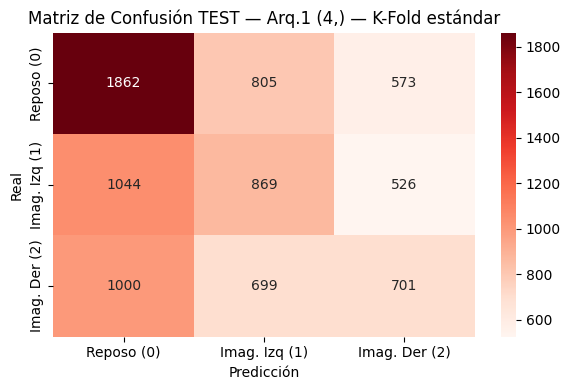

**Figura 5. Matriz de confusión K-FOLD (5 niveles)**


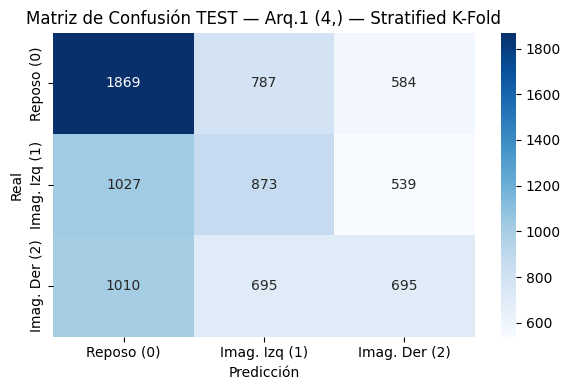

**Figura 6. Matriz de confusión Stratified K-fold**

Se evaluaron dos estrategias de particionamiento sobre la Arquitectura 1
(capa oculta de 4 neuronas) para seleccionar la más adecuada dado el
desbalance de clases del dataset (Reposo: 3240, Imag. Izq: 2439, Imag. Der: 2400).


Los resultados fueron: 

| Métrica | KFold | StratifiedKFold |
|---------|-------|----------------|
| Accuracy TEST promedio | 0.4248 | 0.4254 |
| F1 Macro TEST promedio | 0.4052 | 0.4053 |
| Rango accuracy TEST | 0.410 – 0.448 | 0.415 – 0.433 |
| Diagnóstico fit | Good fit ✓ (5/5) | Good fit ✓ (5/5) |

Ambas estrategias producen accuracy y F1 macro (promedio de los folds) prácticamente idénticos
(~0.425 y ~0.405 respectivamente), con diagnóstico de good fit en todos
los folds debido a los gaps mínimos entre train y test (menores a 0.025
en ambos casos).


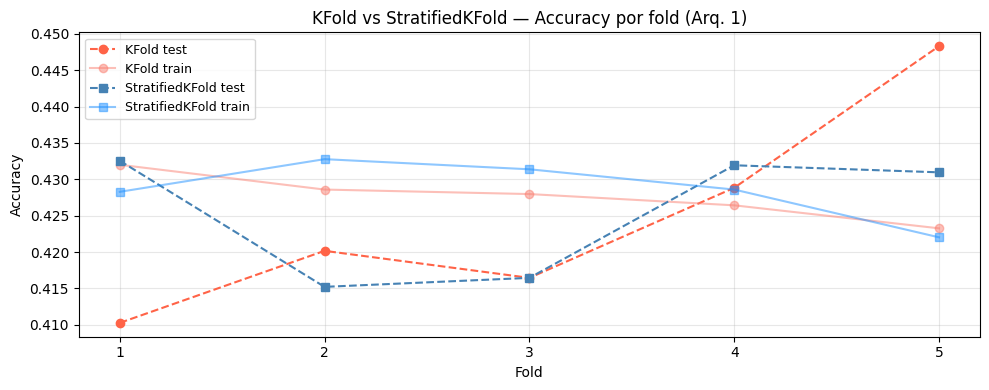

**Figura 7. Comparativa del rendimiento (Accuracy) por iteración entre las estrategias de validación cruzada K-Fold Estándar y Stratified K-Fold, evaluando conjuntos de entrenamiento y prueba**


La gráfica comparativa revela la diferencia relevante entre ambas
estrategias. KFold muestra una tendencia creciente sostenida en el
accuracy de test, pasando de 0.410 en el fold 1 hasta 0.448 en el fold 5,
un rango de 0.038 puntos. Esta variabilidad indica que el rendimiento
depende de cómo queden distribuidas las clases en cada partición aleatoria,
lo cual es un efecto del desbalance entre condiciones. StratifiedKFold en
cambio mantiene el accuracy de test entre 0.415 y 0.433, un rango de solo
0.018 puntos, con una curva visualmente más estable. Esto confirma que al garantizar la proporción de
clases en cada fold las estimaciones son más reproducibles y representativas
del rendimiento real del modelo, por lo cual usaremos para el punto b) esta estrategia de partición de datos.


**Por lo anterior, se escoge el uso de Stratified K-Fold para las 2 arquitecturas restantes de MLP**

## **4.3 Resultados 2 arquitecturas MLP restantes**

Las tres arquitecturas fueron diseñadas siguiendo las reglas heurísticas
para redes MLP con 5 features de entrada y 3 clases de salida:

| Arquitectura | Capas ocultas | Regla aplicada | Justificación |
|---|---|---|---|
| Arq. 1 | (4,) | Regla 1 | Neuronas entre salida (3) y entrada (5) |
| Arq. 2 | (6,) | Regla 2 | 2/3 × entradas + salidas = 2/3×6 + 3 ≈ 6,3 → 6 |
| Arq. 3 | (8,) | Regla 3 | Menos del doble de entradas = menos de 10 → 8 |

### Resultados comparativos

| Métrica | Arq. 1 (4,) | Arq. 2 (6,) | Arq. 3 (8,) |
|---------|------------|------------|------------|
| Acc TRAIN | 0.4286 | 0.4274 | 0.4313 |
| F1 TRAIN | 0.4088 | 0.3953 | 0.4096 |
| Acc TEST | 0.4254 | 0.4207 | 0.4274 |
| F1 TEST | 0.4053 | 0.3894 | 0.4056 |
| Diagnóstico | Good fit ✓ (5/5) | Good fit ✓ (5/5) | Good fit ✓ (5/5) |



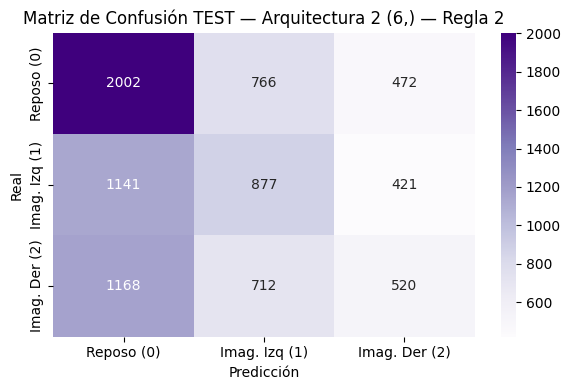

**Figura 8. Evaluación de rendimiento para la Red Neuronal (Arquitectura 2: 6 neuronas): Métricas por iteración y Matriz de Confusión en el conjunto de prueba.**


Accuracy TEST de 0.4207 y F1 macro de 0.3894, los valores más bajos de
las tres arquitecturas. El classification report revela el problema: Imag.
Der cae a f1=0.27 con recall de apenas 0.22, indicando que el modelo
prácticamente no detecta la clase derecha. Aunque el diagnóstico de fit
es bueno, el rendimiento general es inferior.


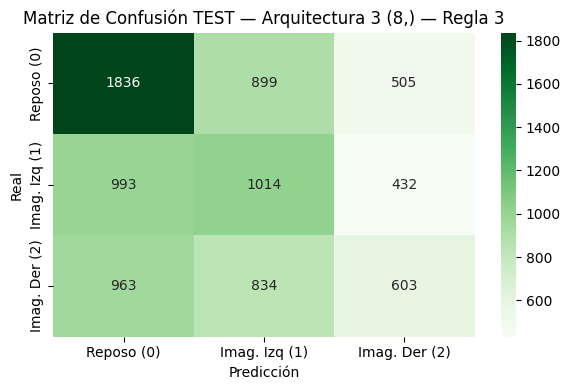

**Figura 9. Evaluación de rendimiento para la Red Neuronal Profunda (Arquitectura 3: 8 neuronas): Métricas por iteración y Matriz de Confusión en el conjunto de prueba.** 

El Accuracy TEST de 0.4274 y F1 macro de 0.4056, muestran los mejores valores de
las tres arquitecturas. El classification report muestra la distribución
más equilibrada: Reposo f1=0.52, Imag. Izq f1=0.39, Imag. Der f1=0.31.
Aunque Imag. Der sigue siendo la clase más difícil, su f1=0.31 es mejor
que en las otras dos arquitecturas. Los gaps train-test son mínimos en
todos los folds (máximo 0.024), confirmando buena generalización.

Por lo anterior se concluye que la Arquitectura 3 (8 neuronas) es la de mejor rendimiento con Acc TEST
de 0.4274 y F1 macro de 0.4056, seguida de cerca por la Arquitectura 1.
La Arquitectura 2 es la de menor rendimiento pese a tener más neuronas
que la 1, lo que sugiere que el número óptimo de neuronas para este
problema no es necesariamente el mayor sino el que mejor equilibra la
capacidad de representación con la complejidad del problema.

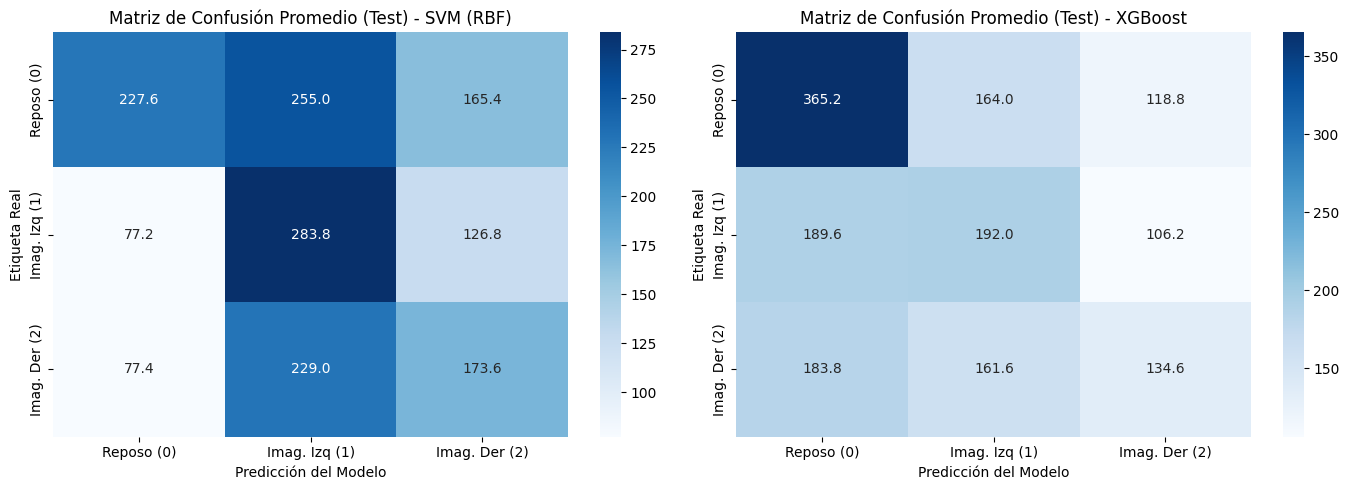

**Figura 10. Evaluación comparativa de algoritmos no lineales avanzados (SVM con kernel RBF y XGBoost): Métricas de rendimiento promedio y Matrices de Confusión promediadas sobre el conjunto de prueba.**

La Figura 10 esta acompañada de la siguiente tabla de resultados que ayuda a validar su relevancia dentro del analisis


| Modelo | Train Accuracy | Train F1 Macro | Test Accuracy | Test F1 Macro | Gap (Train - Test) | Diagnóstico |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **SVM (RBF)** | 0.441 | 0.435 | 0.421 | 0.416 | 0.020 | Good fit ✓ |
| **XGBoost** | 0.581 | 0.568 | 0.426 | 0.406 | 0.155 | Overfitting ⚠ |


La inclusión de modelos no lineales avanzados revela comportamientos contrastantes en la forma en que los algoritmos procesan el espacio de características del EEG:

* Rendimiento Global (Test): A pesar de la sofisticación de ambos algoritmos, la precisión en el conjunto de prueba se mantiene estancada en el mismo rango de los modelos anteriores: 42.1% para SVM y 42.6% para XGBoost.

* Estabilidad vs Sobreajuste: El modelo SVM (RBF) exhibe una fuerte regularización, manteniendo un gap de apenas 2.0% entre entrenamiento (44.1%) y prueba (42.1%), lo que indica un excelente ajuste (Good fit) pero con baja precisión predictiva. Por el contrario, XGBoost muestra una clara tendencia al sobreajuste (Overfitting), elevando su precisión de entrenamiento al 58.1% pero fracasando al generalizar, resultando en un gap masivo del 15.5%.

* Desplazamiento del Sesgo (SVM): La matriz de confusión promedio para SVM revela un fenómeno inusual. A diferencia de los modelos previos que favorecían el estado de "Reposo", el SVM con kernel radial desplaza drásticamente su sesgo predictivo hacia la clase "Imaginación Izquierda". Esto se evidencia en los altos índices de falsos positivos en la columna central: clasifica erróneamente 267.6 épocas de "Reposo" y 236.4 épocas de "Derecha" como si fueran "Izquierda".

* Retorno al Sesgo Basal (XGBoost): Por su parte, la matriz de XGBoost retorna al comportamiento clásico observado en los modelos lineales. Su sesgo mayoritario recae nuevamente sobre la clase "Reposo", la cual concentra el mayor número de predicciones (columna izquierda), generando un alto volumen de falsos negativos para las clases motoras (189.8 confusiones de "Izquierda" y 192.4 de "Derecha" hacia el estado de "Reposo").

El contraste entre SVM y XGBoost ilustra perfectamente el límite representacional de las características (features) extraídas en su estado actual.

El XGBoost, al ser un ensamble basado en árboles de decisión continuos, posee una capacidad altísima para fragmentar el espacio de datos. El elevado Accuracy de entrenamiento (58.1%) demuestra que el algoritmo logra memorizar las complejas y ruidosas relaciones inter-características. Sin embargo, su incapacidad para generalizar (Test Accuracy del 42.6% y F1-Score de 0.406) confirma que dichas reglas memorizadas corresponden a ruido de alta frecuencia o variabilidad inter-sujetos, no al fenómeno fisiológico de desincronización motora (ERD).

Por otro lado, la Máquina de Vectores de Soporte con kernel radial (RBF) proyecta los datos a un espacio dimensional infinito para intentar trazar un hiperplano de separación suave. Al hacerlo, el algoritmo evita memorizar el ruido (logrando un gap de solo 2.0%), pero la matriz de confusión delata que no logró aislar las clases. En lugar de ello, el modelo encontró un mínimo local matemático al proyectar una frontera que simplemente engloba de manera desproporcionada a la clase "Izquierda".





**5. CONCLUSIONES**
--

* El análisis comparativo de las estrategias de particionamiento demostró que el desbalance de clases (Reposo mayoritario frente a tareas motoras) introduce un sesgo de evaluación significativo. El uso de K-Fold estándar generó una falsa inestabilidad inter-iteracional, con rangos de variación de hasta el 3.8% en el Accuracy. La implementación de Stratified K-Fold corrigió este fenómeno, reduciendo la varianza a solo 1.8% y proporcionando una línea base de evaluación confiable y reproducible, confirmando que preservar la distribución poblacional en cada fold es un requisito para este conjunto de datos.

* El rediseño del Perceptrón Multicapa (MLP) utilizando reglas heurísticas (4, 6 y 8 neuronas) resulto adecuado para corregir la generalización del modelo. A diferencia de arquitecturas profundas previas, estas topologías simples lograron un diagnóstico de Good fit consistente, manteniendo gaps entre entrenamiento y prueba inferiores al 2.5%. No obstante, a pesar de encontrar la complejidad estructural adecuada (siendo la Arquitectura 3 la más equilibrada), el rendimiento predictivo se estancó matemáticamente en un ~42.7%. Esto demuestra de forma concluyente que optimizar los hiperparámetros de la red no es suficiente para romper la barrera de clasificación si las características de entrada carecen de separabilidad.

* La problematica predictiva obliga a los distintos algoritmos a fallar de maneras previsibles. Ante la alta superposición de las clases activas demostrada en el análisis estadístico, los modelos basados en árboles (XGBoost) tienden a sobreajustarse severamente memorizando ruido (58.1% en entrenamiento) para luego retornar al sesgo de predecir la clase mayoritaria basal ("Reposo"). Por el contrario, algoritmos que buscan fronteras suaves como las SVM (RBF), evitan el sobreajuste pero convergen en mínimos locales subóptimos, desplazando erráticamente su sesgo hacia una sola clase activa (Imaginación Izquierda).

* El mapa de correlación y la evaluación descriptiva revelaron que el modelo está siendo alimentado con información altamente redundante (correlaciones > 0.85 entre energía Wavelet y PSD) y con una fuerte dependencia inter-hemisférica. Aunque índices como el ASI lograron capturar exitosamente la lateralidad del ERD, su señal se puede perder entre las características colineales. 


***6. REFERENCIAS***
---

[1]M. Zheng, Z. Qian, and T. Zhao, "Motor imagery EEG classification via wavelet-packet synthetic augmentation and entropy-based channel selection,"
*Frontiers in Neuroscience*, vol. 19, Nov. 2025,
doi:10.3389/fnins.2025.1689647

[2]van Putten, M. J. (2007). *The brain symmetry index*. Journal of Clinical Neurophysiology, 24(4), 365-370.

[3] Chen Y, Wang F, Li T, Zhao L, Gong A, Nan W, et al. Considerations and discussions on the clear definition and definite scope of brain-computer interfaces. Front Neurosci [Internet]. 2024;18:1449208. Disponible en: http://dx.doi.org/10.3389/fnins.2024.1449208

[3] Hjorth, B. (1970). *EEG analysis based on time domain properties*. Electroencephalography and Clinical Neurophysiology, 29(3), 306-310.

